In [10]:
pip install opencv-python

In [11]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt


이미지 데이터 전처리 방법을 정의

In [12]:
import zipfile

with zipfile.ZipFile('/content/catanddog.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/catanddog')


In [13]:

data_path='/content/catanddog/train'

transform=transforms.Compose(
    [
        transforms.Resize([256,256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

train_dataset=torchvision.datasets.ImageFolder(
    data_path, transform=transform
)
train_loader=DataLoader(
    train_dataset, batch_size=32, num_workers=8, shuffle=True
)
print(len(train_dataset))

385


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


학습에 사용될 이미지 출력

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


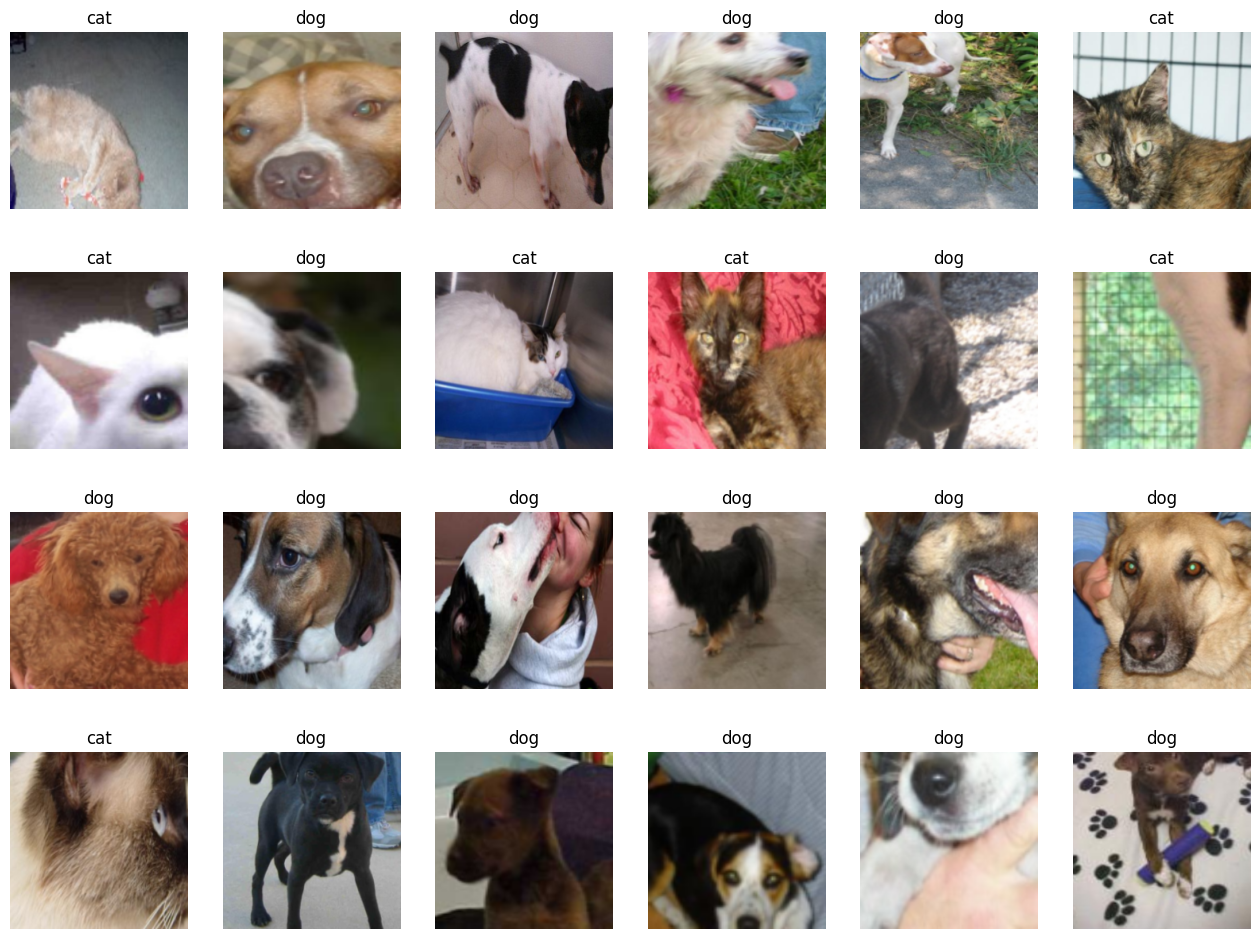

In [14]:
import numpy as np
samples, labels = next(iter(train_loader))
classes={0:'cat', 1:'dog'}
fig=plt.figure(figsize=(16,24))
for i in range(24):
  a=fig.add_subplot(4,6, i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(),(1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

사전 훈련된 모델 내려받기

In [15]:
resnet18=models.resnet18(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 64.6MB/s]


사전 훈련된 모델의 파라미터 학습 유무 지정

In [16]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad=False

set_parameter_requires_grad(resnet18)

ResNet18에 완전 연결층 추가

In [17]:
resnet18.fc=nn.Linear(512,2)

모델의 파라미터 값 확인

In [18]:
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[ 0.0421, -0.0375, -0.0228,  ...,  0.0366, -0.0017,  0.0354],
        [ 0.0237, -0.0107,  0.0289,  ..., -0.0143, -0.0414, -0.0054]])
fc.bias tensor([ 0.0127, -0.0369])


모델 객체 생성 및 손실 함수 정의

In [19]:
model=models.resnet18(pretrained=True)

#모델의 합성곱층 가중치 고정
for param in model.parameters():
  param.requires_grad=False

#완전 연결층 학습
model.fc=torch.nn.Linear(512,2)
for param in model.fc.parameters():
  param.requires_grad=True

optimizer=torch.optim.Adam(model.fc.parameters())
cost=torch.nn.CrossEntropyLoss() # 손실함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

모델 학습을 위한 함수 생성




In [20]:
def train_model(model, dataloaders, criterion, optimizer, device,
                num_epochs=13, is_train=True):

    since = time.time()

    acc_history = []
    loss_history = []
    best_acc = 0.0

    # 모델을 GPU 또는 CPU로 이동
    model = model.to(device)

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        model.train()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:

            # 입력 데이터와 정답을 동일한 device로 이동
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            # 오차 누적
            running_loss += loss.item() * inputs.size(0)

            # 정답 개수 누적
            running_corrects += torch.sum(preds == labels.data)

        # 평균 Loss와 Accuracy 계산
        epoch_loss = running_loss / len(dataloaders.dataset)

        epoch_acc = (
            running_corrects.double()
            / len(dataloaders.dataset)
        )

        print(
            'Loss: {:.4f} Acc: {:.4f}'.format(
                epoch_loss,
                epoch_acc
            )
        )

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)

        # 모델 저장
        torch.save(
            model.state_dict(),
            os.path.join(
                '/content/catanddog/',
                '{0:0=2d}.pth'.format(epoch)
            )
        )

        print()

    time_elapsed = time.time() - since

    print(
        'Training complete in {:.0f}m {:.0f}s'.format(
            time_elapsed // 60,
            time_elapsed % 60
        )
    )

    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history, loss_history

파라미터 학습 결과를 옵티마이저에 전달

In [21]:
params_to_update=[]
for name, param in resnet18.named_parameters():
  if param.requires_grad==True:
    params_to_update.append(param)
    print("\t", name)

optimizer=optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


모델 학습

In [22]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion=nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist=train_model(resnet18, train_loader, criterion, optimizer, device)


Epoch 0/12
----------
Loss: 0.6208 Acc: 0.6234

Epoch 1/12
----------
Loss: 0.3737 Acc: 0.8675

Epoch 2/12
----------
Loss: 0.3460 Acc: 0.8338

Epoch 3/12
----------
Loss: 0.3570 Acc: 0.8234

Epoch 4/12
----------
Loss: 0.2661 Acc: 0.9065

Epoch 5/12
----------
Loss: 0.3012 Acc: 0.8416

Epoch 6/12
----------
Loss: 0.2090 Acc: 0.9377

Epoch 7/12
----------
Loss: 0.2468 Acc: 0.8909

Epoch 8/12
----------
Loss: 0.2189 Acc: 0.9169

Epoch 9/12
----------
Loss: 0.2226 Acc: 0.9039

Epoch 10/12
----------
Loss: 0.2172 Acc: 0.8961

Epoch 11/12
----------
Loss: 0.2328 Acc: 0.8987

Epoch 12/12
----------
Loss: 0.2505 Acc: 0.8753

Training complete in 0m 37s
Best Acc: 0.937662


테스트 데이터 호출 및 전처리

In [23]:
test_path="/content/catanddog/test"

transform=transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)

test_dataset=torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader=torch.utils.data.DataLoader(
    test_dataset, batch_size=32, num_workers=1, shuffle=True
)

print(len(test_dataset))

98


테스트 데이터 평가함수 생성

In [24]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('/content/catanddog/' + '*.pth')
    saved_models.sort()

    print('saved_model', saved_models)

    # 모델을 device로 이동
    model = model.to(device)

    for model_path in saved_models:
        print('loading model', model_path)

        # 저장된 모델 불러오기
        model.load_state_dict(
            torch.load(model_path, map_location=device)
        )

        model.eval()

        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(inputs)

                _, preds = torch.max(outputs, 1)

            running_corrects += torch.sum(preds == labels)

        epoch_acc = (
            running_corrects.double()
            / len(dataloaders.dataset)
        )

        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())

        print()

    time_elapsed = time.time() - since

    print(
        'Validation complete in {:.0f}m {:.0f}s'.format(
            time_elapsed // 60,
            time_elapsed % 60
        )
    )

    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history

테스트 데이터를 평가 함수에 적용

In [25]:
val_acc_hist=eval_model(resnet18, test_loader, device)

saved_model ['/content/catanddog/00.pth', '/content/catanddog/01.pth', '/content/catanddog/02.pth', '/content/catanddog/03.pth', '/content/catanddog/04.pth', '/content/catanddog/05.pth', '/content/catanddog/06.pth', '/content/catanddog/07.pth', '/content/catanddog/08.pth', '/content/catanddog/09.pth', '/content/catanddog/10.pth', '/content/catanddog/11.pth', '/content/catanddog/12.pth']
loading model /content/catanddog/00.pth
Acc: 0.7653

loading model /content/catanddog/01.pth
Acc: 0.9184

loading model /content/catanddog/02.pth
Acc: 0.8776

loading model /content/catanddog/03.pth
Acc: 0.9184

loading model /content/catanddog/04.pth
Acc: 0.9490

loading model /content/catanddog/05.pth
Acc: 0.9184

loading model /content/catanddog/06.pth
Acc: 0.9592

loading model /content/catanddog/07.pth
Acc: 0.9286

loading model /content/catanddog/08.pth
Acc: 0.9184

loading model /content/catanddog/09.pth
Acc: 0.9694

loading model /content/catanddog/10.pth
Acc: 0.9184

loading model /content/cata

훈련과 테스트 데이터의 정확도를 그래프로 확인

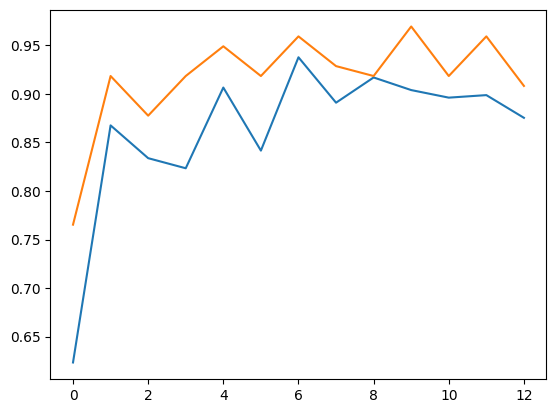

In [26]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

훈련 데이터의 오차에 대한 그래프 확인

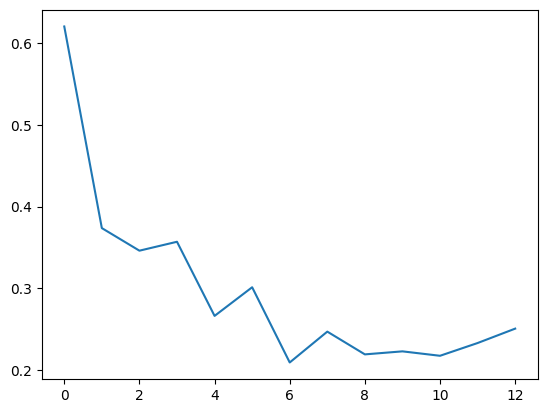

In [27]:
plt.plot(train_loss_hist)
plt.show()

예측 이미지 출력을 위한 전처리 함수

In [28]:
def im_convert(tensor):
  image=tensor.clone().detach().numpy()
  image=image.transpose(1,2,0)
  imge=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
  image=image.clip(0,1)
  return image

개와 고양이 예측 결과 출력

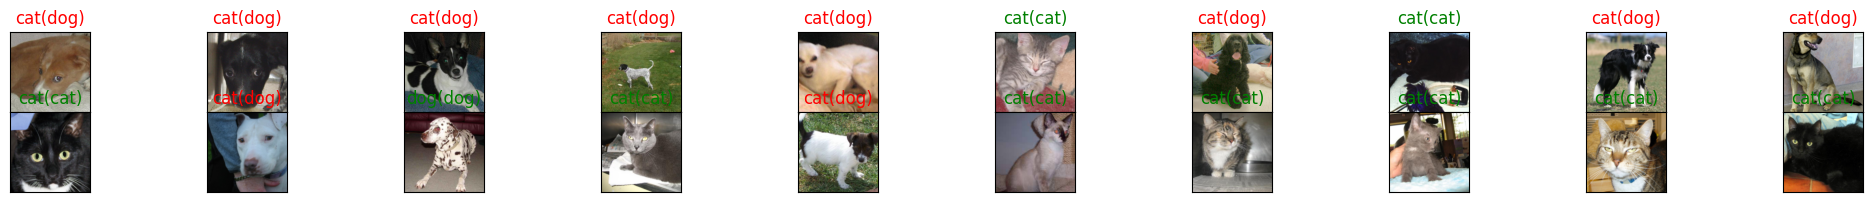

In [29]:
classes = {0: 'cat', 1: 'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)

# 모델과 입력 데이터를 같은 device로 이동
images = images.to(device)
labels = labels.to(device)

model = model.to(device)
model.eval()

with torch.no_grad():
    output = model(images)
    _, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25, 4))

for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])

    # 화면 출력용으로 CPU로 이동
    plt.imshow(im_convert(images[idx].cpu()))

    ax.set_title(
        "{}({})".format(
            classes[preds[idx].item()],
            classes[labels[idx].item()]
        ),
        color=("green" if preds[idx] == labels[idx] else "red")
    )

plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
plt.show()

설명 가능한 CNN: explainable CNN
특성 맵 시각화

필요한 라이브러리 호출

In [30]:
pip install pillow

In [31]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


설명가능한 네트워크 생성

In [32]:
class XAI(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 512, bias=False),
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 512)
        x = self.classifier(x)
        return F.log_softmax(x)

모델 객체화

In [50]:
model=XAI()
model.to(device)
model.eval()

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

특성맵 확인을 위하 클래스 정의

In [51]:
class LayerActivations:
    def __init__(self, model, layer_num):
        self.features = None
        self.hook = model[layer_num].register_forward_hook(self.hook_fn)

    def hook_fn(self, module, input, output):
        self.features = output.detach().cpu().numpy()

    def remove(self):
        self.hook.remove()

이미지 호출

/tmp/ipykernel_1192/1716070603.py:86: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


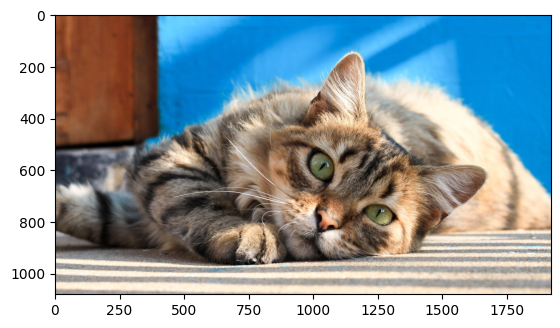

In [52]:
img = cv2.imread("/content/cat.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)

img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0)

device = next(model.parameters()).device
img = img.to(device)

result = LayerActivations(model.features, 0)

model(img)

activations = result.features

특성맵 확인

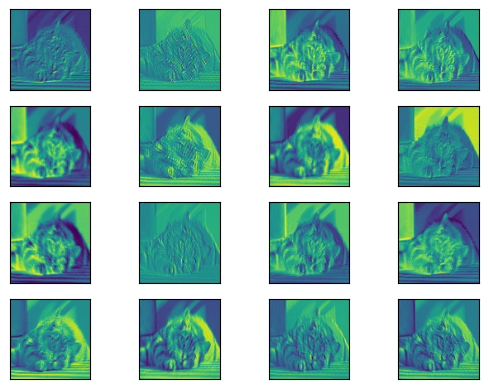

<Figure size 1200x800 with 0 Axes>

In [53]:
fig, axes=plt.subplots(4,4)
fig=plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis=axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

20번째 계층에 대한 특성 맵

In [54]:
result=LayerActivations(model.features,20)

model(img)
activations=result.features

/tmp/ipykernel_1192/1716070603.py:86: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


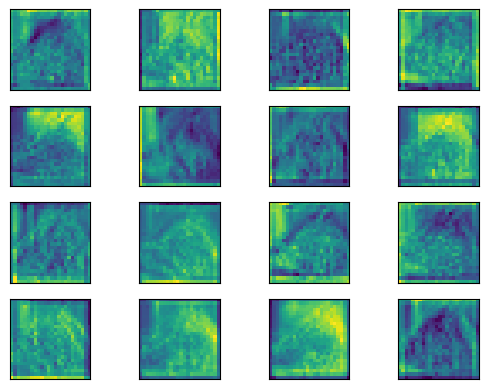

<Figure size 1200x800 with 0 Axes>

In [55]:
fig, axes=plt.subplots(4,4)
fig=plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis=axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

40번째 특성맵

In [56]:
result=LayerActivations(model.features,40)

model(img)
activations=result.features

/tmp/ipykernel_1192/1716070603.py:86: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


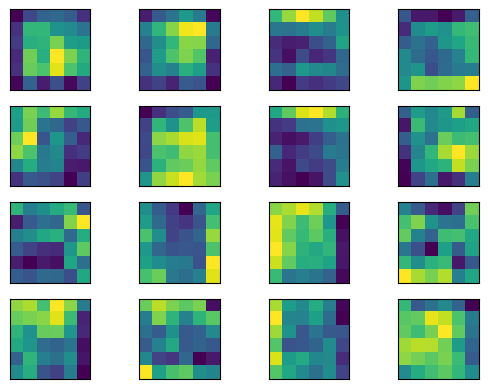

<Figure size 1200x800 with 0 Axes>

In [57]:
fig, axes=plt.subplots(4,4)
fig=plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis=axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()